# Analiza 2: Uticaj "pit stop-a" na tempo (upareni t-test)

**Hipoteza:** Neposredno nakon "pit stop-a" (kada vozač izađe na svežim gumama) tempo vozača
(prosečno vreme kruga) se značajno razlikuje od tempa neposredno pre zaustavljanja.

**Metod:** Za svaki "pit stop" upoređujemo prosek poslednja 3 "čista" kruga pre zaustavljanja
sa prosekom prve 3 čista kruga posle zaustavljanja (izuzimajući sam "in/out lap" koji je
inherentno spor zbog vožnje kroz boks). Pored toga, uklanjamo krugove koji su anomalno spori
*za tog konkretnog vozača* (z-score po vozaču, ne samo globalni kvantil) - ovo hvata krugove
pod safety car-om/saobraćajem koji nisu formalno obeleženi kao "out lap" ali bi bez razloga
iskrivili poređenje pre/posle za taj jedan "pit stop". Koristimo upareni t-test
(`scipy.stats.ttest_rel`) jer posmatramo iste vozače/stintove pre i posle - upareni dizajn
poništava razlike u apsolutnom tempu između vozača.

**Kome je ovo bitno:** Inženjerima strategije - govori im koliko realno "pit stop" menja tempo
(effect vožnje na svežim gumama), što ulazi direktno u model "kada stati" (undercut/overcut
proračune).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("F1Analysis").getOrCreate()


DATA_DIR = "../data/processed"


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/07 00:08:46 WARN Utils: Your hostname, Ognjens-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.55 instead (on interface en0)
26/07/07 00:08:46 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/07 00:08:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
from pyspark.sql import functions as F

laps = spark.read.csv(f"{DATA_DIR}/laps.csv", header=True, inferSchema=True)
pit = spark.read.csv(f"{DATA_DIR}/pit.csv", header=True, inferSchema=True)

laps_clean = laps.filter((F.col("is_pit_out_lap") == False) & F.col("lap_duration").isNotNull())
pit.select("driver_number", "lap_number").show(20)


+-------------+----------+
|driver_number|lap_number|
+-------------+----------+
|           16|         1|
|           16|        16|
|           44|        21|
|           11|        21|
|           63|        22|
|            1|        23|
|            4|        23|
|           16|        33|
|           63|        46|
|            1|        51|
|            4|        51|
|           11|        51|
|           16|        51|
|           44|        53|
|            1|        64|
+-------------+----------+



In [3]:
laps_pdf = laps_clean.select("driver_number", "lap_number", "lap_duration").toPandas()
pit_pdf = pit.select("driver_number", "lap_number").toPandas().rename(columns={"lap_number": "pit_lap"})


Z_THRESHOLD = 2.5
laps_pdf["z"] = laps_pdf.groupby("driver_number")["lap_duration"].transform(
    lambda s: (s - s.mean()) / s.std()
)
n_before = len(laps_pdf)
laps_pdf = laps_pdf[laps_pdf["z"].abs() <= Z_THRESHOLD].drop(columns="z")
print(f"Uklonjeno {n_before - len(laps_pdf)} anomalno sporih krugova (|z| > {Z_THRESHOLD}) po vozaču")

before_after = []
N_LAPS = 3
for _, row in pit_pdf.iterrows():
    driver, pit_lap = row["driver_number"], row["pit_lap"]
    driver_laps = laps_pdf[laps_pdf["driver_number"] == driver].sort_values("lap_number")

    before = driver_laps[(driver_laps["lap_number"] < pit_lap) &
                          (driver_laps["lap_number"] >= pit_lap - N_LAPS)]["lap_duration"]
    after = driver_laps[(driver_laps["lap_number"] > pit_lap) &
                         (driver_laps["lap_number"] <= pit_lap + N_LAPS)]["lap_duration"]

    if len(before) >= 2 and len(after) >= 2:
        before_after.append({
            "driver_number": driver, "pit_lap": pit_lap,
            "avg_before": before.mean(), "avg_after": after.mean(),
        })

pit_impact = pd.DataFrame(before_after)
pit_impact["delta"] = pit_impact["avg_after"] - pit_impact["avg_before"]
pit_impact


Uklonjeno 9 anomalno sporih krugova (|z| > 2.5) po vozaču


,driver_number,pit_lap,avg_before,avg_after,delta
0,16,16,71.946333,71.1780,-0.768333
1,44,21,71.845667,70.2135,-1.632167
2,11,21,71.874333,70.6545,-1.219833
3,63,22,71.580333,69.6775,-1.902833
4,1,23,71.465667,69.6360,-1.829667
5,4,23,71.308000,69.5630,-1.745000
6,16,33,70.606000,69.9745,-0.631500
7,63,46,71.190333,69.2260,-1.964333
8,1,51,70.547000,68.7805,-1.766500
9,4,51,70.588000,68.2225,-2.365500


In [4]:
from scipy import stats

t_stat, p_value = stats.ttest_rel(pit_impact["avg_before"], pit_impact["avg_after"])
print(f"Upareni t-test: t = {t_stat:.3f}, p = {p_value:.4f}")
print(f"Prosečna promena tempa nakon pit stopa: {pit_impact['delta'].mean():+.3f} s po krugu")


Upareni t-test: t = 10.017, p = 0.0000
Prosečna promena tempa nakon pit stopa: -1.492 s po krugu


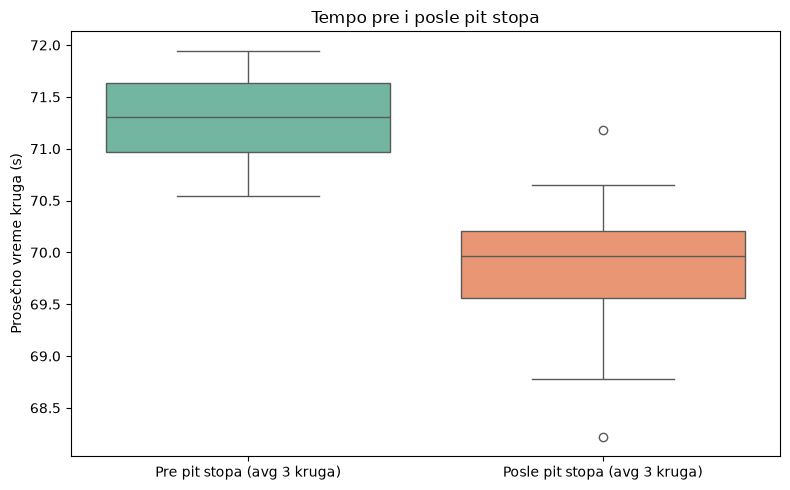

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=pit_impact[["avg_before", "avg_after"]].rename(
    columns={"avg_before": f"Pre pit stopa (avg {N_LAPS} kruga)", "avg_after": f"Posle pit stopa (avg {N_LAPS} kruga)"}),
    ax=ax, palette="Set2")
ax.set_ylabel("Prosečno vreme kruga (s)")
ax.set_title("Tempo pre i posle pit stopa")
plt.tight_layout()
plt.show()


**Zaključak:** Ako je p < 0.05, razlika u tempu pre/posle "pit stopa" je statistički
značajna - tj. sveže gume merljivo menjaju tempo vozača (obično ga ubrzavaju), što potvrđuje da
"pit stop" nije samo gubitak vremena u boksu nego i realna promena performansi na stazi u
narednim krugovima.